In [1]:
"""
Two-panel figure: trapped Poincare map (rho vertical) + firm3d Omega_eta.

Matches poincare_rho_omega_bundle/README.md:

  Left  : firm3d trapped map, rho = sqrt(s) vertical, eta horizontal with
          pi/2 ticks (marker "o", s=0.5, edgecolors none).
  Right : Omega_eta from the single eta=0 field line (no alpha average),
          sharing the rho axis, dashed line at Omega_eta = 0.

  Exact recipe (README):
    --bcrit 5.962 6.469 --map-dir ../data --exclude-librating 6.469
    --subsample-rho 2 --subsample-eta 2 --firm3d-eta0 --no-desc

Sign: firm3d Omega is negated into DESC's sign convention (README note 2).
"""

from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np


In [2]:
FontSize = 22
label_kw = {"fontfamily": "Times New Roman", "fontsize": FontSize}
tick_labelsize = FontSize - 2

plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "mathtext.fontset": "custom",
        "mathtext.rm": "Times New Roman",
        "mathtext.it": "Times New Roman:italic",
        "mathtext.bf": "Times New Roman:bold",
        "figure.figsize": (6.4, 4.8)
    }
)


# Default axes box in figure coordinates (0–1); tune once, reuse everywhere
AXES_MARGINS = dict(left=0.07, right=0.98, bottom=0.16, top=0.96) # percentages of the figure height/width

plt.rcParams.update(
    {
        "figure.subplot.left": AXES_MARGINS["left"],
        "figure.subplot.right": AXES_MARGINS["right"],
        "figure.subplot.bottom": AXES_MARGINS["bottom"],
        "figure.subplot.top": AXES_MARGINS["top"],
        # optional: spacing for multi-panel figures
        "figure.subplot.wspace": 0.25,
        "figure.subplot.hspace": 0.25,
    }
)


# apply to figures to apply even if using tight_layout
def apply_standard_axes(fig):
    fig.subplots_adjust(**AXES_MARGINS)



In [3]:
from types import SimpleNamespace

# Include librating orbits at 6.469. subsample_eta must be 1: the island sits on
# odd eta-grid indices (ie=17), so subsample_eta=2 drops all 4 librating orbits.
args = SimpleNamespace(
    bcrit=["5.962", "6.469"],
    map_dir="../data",
    map_tag="rhogrid_res96",
    desc="../data/desc_omega_eta_rho.npz",  # unused with desc_curve=False
    out_dir="../figures",
    flip_desc=False,  # firm3d Omega negated -> DESC sign (README note 2)
    ns_poinc=120,
    neta_poinc=21,
    subsample_rho=2,
    subsample_eta=1,
    desc_curve=False,       # --no-desc: right panel is firm3d eta=0 only
    firm3d_eta0=True,       # Omega_eta from single eta=0 field line
    exclude_librating=[],   # show the island at 6.469
)


In [4]:
out_dir = Path(args.out_dir)
out_dir.mkdir(parents=True, exist_ok=True)
desc = np.load(args.desc) if args.desc_curve else None


findfont: Failed to find font weight normal, now using 0.


  Bcrit 5.962: plotted 731 of 1460 trajectories; thinned out 729 by grid subsampling
  Bcrit 5.962: firm3d eta=0 profile from 62 trajectories
wrote ../figures/poincare_rho_and_omega_eta_Bcrit_5.962.png and .pdf


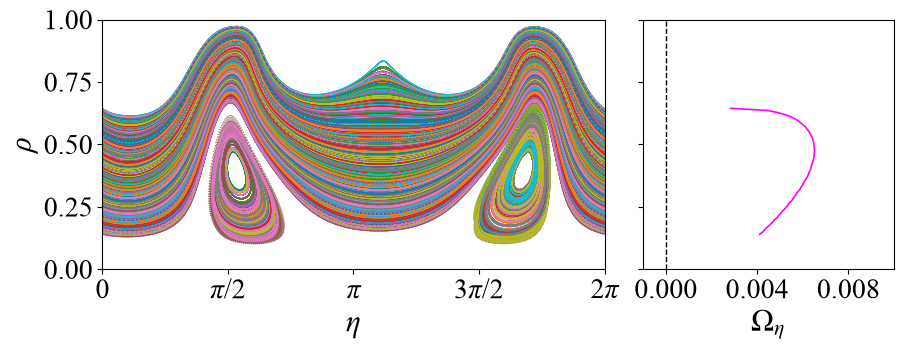

  Bcrit 6.469: plotted 713 of 1429 trajectories; thinned out 716 by grid subsampling
  Bcrit 6.469: firm3d eta=0 profile from 66 trajectories
wrote ../figures/poincare_rho_and_omega_eta_Bcrit_6.469.png and .pdf


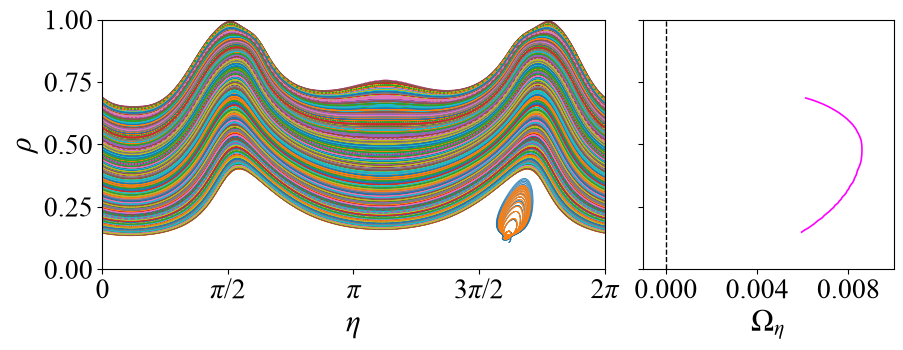

In [6]:
for bc in args.bcrit:
    fig, (axL, axR) = plt.subplots(
        1, 2, figsize=(9.0, 3.6), gridspec_kw={"width_ratios": [2, 1]},
    )

    # ---- left: firm3d Poincare map, rho vertical -------------------
    f = Path(args.map_dir) / f"{args.map_tag}_poincare_data_Bcrit_{bc}.npz"
    with np.load(f, allow_pickle=True) as d:
        s_all, e_all = d["s_all"], d["etas_all"]
        t_all = d["t_all"]
        modBcrit = float(d["modBcrit"])
    # Map each trajectory back to its (rho, eta) launch-grid index so the grid
    # can be thinned without re-tracing. The run used --rho-grid, i.e. rho
    # uniform on (0,1] and s = rho**2.
    rho_grid = np.linspace(0, 1, args.ns_poinc + 1, endpoint=False)[1:]
    eta_grid = np.linspace(0, 2 * np.pi, args.neta_poinc, endpoint=False)
    keep_rho = set(range(0, args.ns_poinc, args.subsample_rho))
    keep_eta = set(range(0, args.neta_poinc, args.subsample_eta))

    drop_lib = bc in args.exclude_librating
    n_drop = n_thin = n_plot = 0
    for i in range(len(e_all)):
        s = np.asarray(s_all[i], float)
        e_raw = np.asarray(e_all[i], float)

        if args.subsample_rho > 1 or args.subsample_eta > 1:
            ir = int(np.argmin(np.abs(rho_grid - np.sqrt(s[0]))))
            ie = int(np.argmin(np.abs(eta_grid - np.mod(e_raw[0], 2 * np.pi))))
            if ir not in keep_rho or ie not in keep_eta:
                n_thin += 1
                continue

        if drop_lib and (e_raw.max() - e_raw.min()) < 2 * np.pi:
            n_drop += 1  # librating: bounded in unwrapped eta
            continue
        n_plot += 1
        e = np.mod(e_raw, 2 * np.pi)
        m = min(s.size, e.size)
        axL.scatter(
            e[:m], np.sqrt(s[:m]),  # rho = sqrt(s)
            marker="o", s=0.5, edgecolors="none", rasterized=True,
        )
    print(
        f"  Bcrit {bc}: plotted {n_plot} of {len(e_all)} trajectories"
        + (f"; thinned out {n_thin} by grid subsampling" if n_thin else "")
        + (f"; omitted {n_drop} librating" if n_drop else "")
    )
    axL.set_xlim(0, 2 * np.pi)
    axL.set_ylim(0, 1)
    axL.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    axL.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    axL.set_xlabel(r"$\eta$", **label_kw)
    axL.set_ylabel(r"$\rho$", **label_kw)
    axL.tick_params("both", labelsize=tick_labelsize)

    # ---- right: Omega_eta from single eta=0 field line (README) ------
    if args.desc_curve:
        rho = desc[f"rho_{bc}"]
        Om = desc[f"Omega_{bc}"]
        if args.flip_desc:
            Om = -Om
        axR.plot(Om, rho, "-", color="magenta", lw=1.6, label="DESC")

    if args.firm3d_eta0:
        # Single field line: trajectories launched at eta = 0 only.
        # No alpha average -- one field line (README lines 15-16).
        r0, om0 = [], []
        for i in range(len(e_all)):
            e_raw = np.asarray(e_all[i], float)
            if int(np.argmin(np.abs(eta_grid - np.mod(e_raw[0], 2 * np.pi)))) != 0:
                continue
            s = np.asarray(s_all[i], float)
            t = np.asarray(t_all[i], float)
            if len(s) < 2:
                continue
            mdt = np.mean(t[1:])  # t_all holds per-return intervals
            if not np.isfinite(mdt) or mdt <= 0:
                continue
            # normalized precession frequency = <delta_eta>/2pi
            r0.append(np.sqrt(s[0]))
            om0.append((np.mean(np.diff(e_raw)) / mdt) / (2 * np.pi / mdt))
        r0, om0 = np.array(r0), np.array(om0)
        o = np.argsort(r0)
        sgn = 1.0 if args.flip_desc else -1.0  # put firm3d in DESC's sign
        axR.plot(
            sgn * om0[o], r0[o], "-", color="magenta", lw=1.2,
            label=r"firm3d $\eta=0$",
        )
        print(f"  Bcrit {bc}: firm3d eta=0 profile from {len(r0)} trajectories")

    axR.axvline(0, color="k", ls="--", lw=1.0)
    if args.firm3d_eta0 and args.desc_curve:
        axR.legend(fontsize=7, loc="best")
    axR.set_ylim(0, 1)
    axR.set_yticklabels([])
    axR.set_xlabel(r"$\Omega_\eta$", **label_kw)
    axR.set_xlim(-0.001, 0.010)
    axR.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(3))
    axR.tick_params("both", labelsize=tick_labelsize)

    fig.tight_layout()
    outfile = out_dir / f"poincare_rho_and_omega_eta_Bcrit_{bc}.png"
    fig.savefig(outfile, dpi=200)
    fig.savefig(outfile.with_suffix(".pdf"))
    print(f"wrote {outfile} and .pdf")
    plt.show()
